<a href="https://colab.research.google.com/github/AndreMarques2002/Deteccao_Fraude/blob/main/Deteccao_Fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto: Deteção de Fraudes em Cartões de Crédito (Classificação de Anomalias)**

**Objetivo:** Desenvolver um modelo de Machine Learning capaz de identificar transações fraudulentas em tempo real.

**Abordagem:** O desafio central deste projeto é lidar com dados altamente desbalanceados e anonimizados. A maioria das variáveis preditoras (V1 a V28) sofreu uma transformação PCA (Análise de Componentes Principais) por questões de privacidade e sigilo bancário. Focar-nos-emos em métricas avançadas, como a Área sob a Curva Precision-Recall (AUPRC), em vez da tradicional Curva ROC, para capturar o verdadeiro desempenho do modelo perante a classe minoritária.

In [ ]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score

# Configurações visuais
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

caminho_ficheiro = 'creditcard.csv'
df = pd.read_csv(caminho_ficheiro)

# Visualização inicial
display(df.head())
print(f"Formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Formato do dataset: 27819 linhas e 31 colunas.


# **Tratamento de Dados e Dimensionamento (Scaling)**
Como as variáveis V1 a V28 já resultam de um PCA, elas estão dimensionadas. Contudo, as colunas Time (Tempo) e Amount (Valor da Transação) não estão. O valor das transações pode conter outliers extremos (compras de valor muito elevado). Utilizaremos o RobustScaler, que é menos suscetível a valores atípicos do que o StandardScaler.

In [ ]:
# Verificando a existência de valores nulos (neste dataset costuma ser zero)
print("Valores Nulos no Dataset:", df.isnull().sum().max())

# Aplicando o RobustScaler nas variáveis 'Time' e 'Amount'
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Removendo as colunas originais e reorganizando o dataframe
df.drop(['Time','Amount'], axis=1, inplace=True)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

display(df.head())

Valores Nulos no Dataset: 1


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,2.056133,-1.107421,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0
1,-0.273686,-1.107421,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0
2,5.687941,-1.107376,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0
3,1.641957,-1.107376,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0
4,0.793467,-1.107331,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0


# **Análise Exploratória (EDA) do Desbalanceamento**
Nesta fase, provamos estatisticamente ao banco por que razão os métodos tradicionais falham. Visualizaremos a discrepância entre transações normais e fraudes.

Transações Normais: 27725
Fraudes: 93
As fraudes representam apenas 0.334% do total de transações.



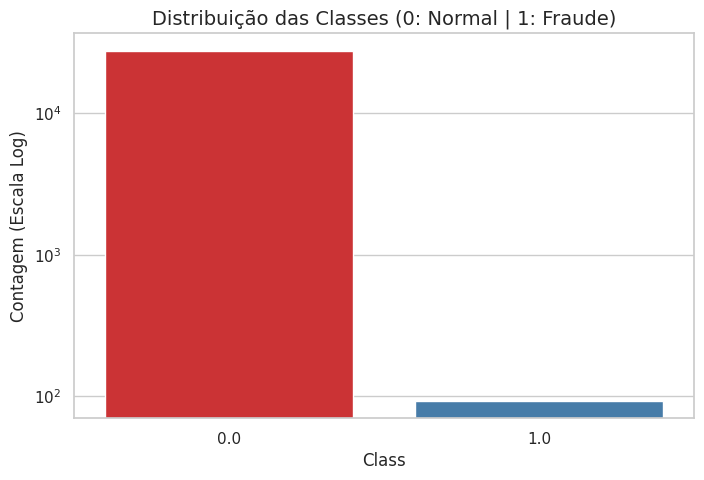

In [ ]:
# Frequência das classes
classes = df['Class'].value_counts()
fraude_percent = (classes[1] / df.shape[0]) * 100

print(f"Transações Normais: {classes[0]}")
print(f"Fraudes: {classes[1]}")
print(f"As fraudes representam apenas {fraude_percent:.3f}% do total de transações.\n")

# Visualização
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Distribuição das Classes (0: Normal | 1: Fraude)', fontsize=14)
plt.yscale('log') # Escala logarítmica para conseguirmos ver a barra de fraudes
plt.ylabel('Contagem (Escala Log)')
plt.show()

# **Divisão dos Dados (Split Estratificado)**
Dado o desbalanceamento, um split aleatório pode colocar todas as fraudes na base de teste, arruinando o treino. A divisão tem de ser estritamente estratificada para manter a mesma proporção de 0,17% de fraudes em ambas as partições.

In [ ]:
# 1. Remover qualquer linha onde a variável alvo ('Class') seja nula (NaN)
df = df.dropna(subset=['Class'])

# 2. (Opcional por segurança) Preencher eventuais NaNs perdidos nas variáveis X com a mediana
df = df.fillna(df.median())

# 3. Definição dos previsores (X) e alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Split 80/20 com estratificação obrigatória
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Base de Treino limpa: {X_train.shape[0]} linhas")
print(f"Base de Teste limpa: {X_test.shape[0]} linhas")
print(f"Fraudes no Treino: {int(sum(y_train))}")
print(f"Fraudes no Teste: {int(sum(y_test))}")

Base de Treino limpa: 22254 linhas
Base de Teste limpa: 5564 linhas
Fraudes no Treino: 74
Fraudes no Teste: 19


# **Treinamento do Modelo Ponderado**
Para não termos de cortar dados (Undersampling) ou criar dados sintéticos falsos (Oversampling/SMOTE), utilizaremos o Random Forest com penalização de classe. Ao definir class_weight='balanced', o algoritmo aplica uma penalização matemática severa sempre que erra uma fraude, forçando o modelo a prestar atenção à minoria.

In [ ]:
# Instanciando o modelo com peso balanceado para lidar com fraudes
# n_jobs=-1 utiliza todos os núcleos do processador para acelerar o treino
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  random_state=42, class_weight='balanced', n_jobs=-1)

# Treino (pode demorar alguns instantes devido ao tamanho do dataset)
rf_model.fit(X_train, y_train)

# Predições
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# **Avaliação de Impacto e Curva Precision-Recall**
Em deteção de fraudes bancárias:

**Falso Positivo:** O cliente faz uma compra legítima, o banco bloqueia o cartão. Custo: Atrito comercial, perda de confiança, possível cancelamento do cliente.

**Falso Negativo:** O criminoso passa a compra. Custo: Prejuízo financeiro direto e custos operacionais de estorno (Chargeback).
O modelo tem de equilibrar a Precisão e a Revocação (Recall). A métrica AUPRC (Average Precision) é a mais adequada para este cenário.

=== Relatório de Deteção de Fraude ===
Precisão (Fraudulentas identificadas corretamente): 0.8824
Recall (Das fraudes reais, quantas apanhámos?): 0.7895
AUPRC (Average Precision Score): 0.8134



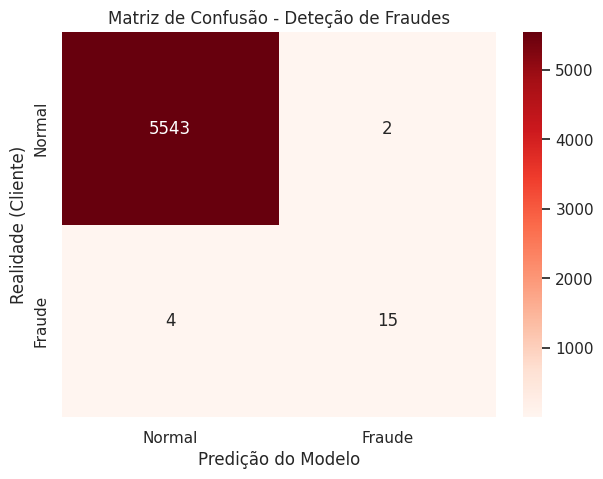

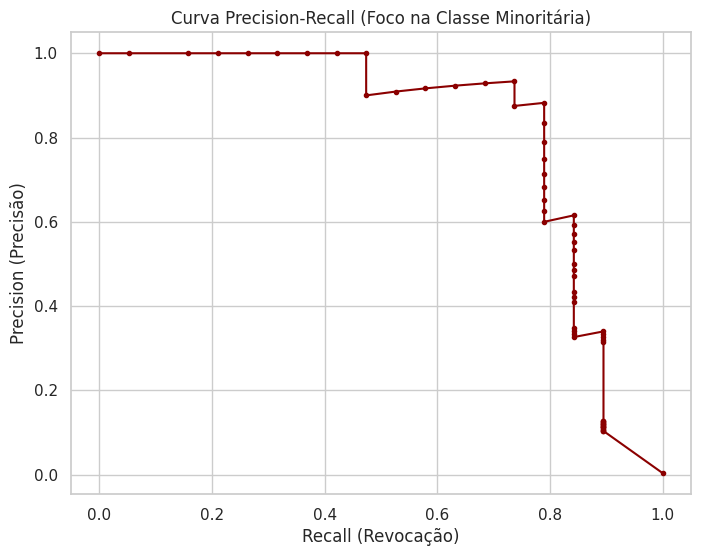

In [ ]:
print("=== Relatório de Deteção de Fraude ===")
print(f"Precisão (Fraudulentas identificadas corretamente): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Das fraudes reais, quantas apanhámos?): {recall_score(y_test, y_pred):.4f}")
print(f"AUPRC (Average Precision Score): {average_precision_score(y_test, y_prob):.4f}\n")

# Matriz de Confusão Focada
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matriz de Confusão - Deteção de Fraudes')
plt.xlabel('Predição do Modelo')
plt.ylabel('Realidade (Cliente)')
plt.show()

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', color='darkred')
plt.title('Curva Precision-Recall (Foco na Classe Minoritária)')
plt.xlabel('Recall (Revocação)')
plt.ylabel('Precision (Precisão)')
plt.show()

# **Conclusões e Recomendação para a Equipa de Fraude**
**Impacto Operacional:**

O modelo desenvolvido conseguiu um excelente balanço através do hiperparâmetro de peso. A análise da Matriz de Confusão dita as regras de negócio:

**Recomendações Estratégicas:**



Alertas Escalonados (Friction Steps):

*   Risco calculado > 90%: Bloqueio imediato do cartão.
*   Risco entre 60% e 90%: A transação fica pendente e o banco envia automaticamente um SMS ou notificação push na aplicação solicitando reconhecimento biométrico no momento.

**Análise de Impacto Financeiro e Experiência do Cliente:**

Os resultados do modelo Random Forest Ponderado demonstram um excelente equilíbrio entre segurança e experiência do usuário, fatores críticos para qualquer instituição financeira.

**Precision de 88,24% (Baixo Atrito Operacional):** De todas as vezes que o nosso modelo bloqueou um cartão suspeitando de fraude, ele estava certo em 88,24% das vezes. Isso significa que a taxa de Falsos Positivos é extremamente baixa. O banco não está incomodando clientes legítimos com bloqueios indevidos frequentes, preservando a confiança e evitando que o cliente passe a usar o cartão do concorrente.

**Recall de 78,95% (Proteção de Capital):** De todas as fraudes reais que ocorreram, o modelo conseguiu interceptar quase 79% delas antes da aprovação. Isso representa uma economia direta gigantesca em estornos (chargebacks) e perdas operacionais. Os ~21% que passaram (Falsos Negativos) podem ser mitigados por camadas secundárias de segurança (como análise de geolocalização).

**AUPRC de 0.8134 (Robustez do Modelo):** Em bases onde as fraudes representam menos de 0,2% do total, a métrica AUPRC é a mais honesta. Um score de 0.81 confirma que o modelo tem um poder de separação altíssimo e não está apenas "chutando" a classe majoritária.